# Setup

In [1]:
# install libraries

In [2]:
# import libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF 
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
summarize ,
poly)
from functools import partial
from sklearn.base import clone
from ISLP.models import sklearn_sm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from ISLP.bart import BART
from scipy.stats import shapiro
from scipy import stats


In [3]:
# check working directory
os.getcwd()

'/Users/LauraSoerineVoldgaard/Desktop'

# Data wrangling and dataset creation

In [4]:
# load data
gini = pd.read_csv('data/gini.csv', index_col=0, skiprows=3) # gini coefficient
gdp = pd.read_csv('data/gdp.csv', index_col=0, skiprows=3) # GDP
inflation = pd.read_csv('data/inflation.csv', index_col=0, skiprows=3) # inflation rate
unemployment = pd.read_csv('data/unemployment.csv', index_col=0, skiprows=3) # unemployment rate
income = pd.read_csv('data/Real wage.csv') # median real earnings
satisfaction = pd.read_csv('data/satisfaction.csv') # satsifaction with personal life and with the US
election_results = pd.read_csv('data/election_results.csv') # electoral outcomes

### Inspect data

In [5]:
gini


,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,44.2,44.6,40.2,57.4,49.4,38.3,NaN,NaN,NaN,NaN
"Yemen, Rep.",YEM,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,54.1,NaN,NaN,NaN,NaN


In [6]:
gdp

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.485815,3.048518,0.951664,-23.466273,15.675519,11.038520,7.657640,6.181751,NaN,NaN
Africa Eastern and Southern,AFE,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-2.182395,5.075379,2.795642,1.790384,2.225029,1.922442,...,0.000238,-0.064991,-0.709407,-5.405934,1.844404,1.068005,-0.604582,0.253854,NaN,NaN
Afghanistan,AFG,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,NaN,NaN,NaN
Africa Western and Central,AFW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-0.251185,1.538542,4.740660,3.086962,1.823450,-3.703529,...,-0.355283,0.330202,0.792058,-6.003416,0.154018,2.064401,1.218110,2.107058,NaN,NaN
Angola,AGO,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.622865,-3.968525,-3.529000,-7.127615,-1.094341,0.991407,-1.808703,1.292933,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.038389,3.057529,5.236697,-5.406902,10.998140,5.339098,9.351075,10.365649,NaN,NaN
"Yemen, Rep.",YEM,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-7.888612,-2.186490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,0.971242,3.066160,4.168016,4.692929,2.909441,1.252170,...,0.498696,-0.137485,-1.380361,-7.678733,3.255620,0.625217,-0.523851,-0.713538,NaN,NaN


In [7]:
inflation

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,NaN,NaN
Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.488234,1.053798,2.675992,0.198228,3.353691,11.580510,4.944324,1.619450,NaN,NaN
"Yemen, Rep.",YEM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.288877,2.102351,1.246275,1.337971,2.534989,4.069019,3.489237,...,5.186187,4.509873,4.102851,3.232388,4.618745,7.039873,6.075244,4.361152,NaN,NaN


In [8]:
unemployment

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,NaN,NaN,11.710,5.679,NaN,NaN,NaN,NaN,NaN
Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.240084,NaN,3.689777,NaN,NaN,3.337512,NaN,NaN,NaN,NaN
Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.431000,16.033,15.806,14.094000,12.885,13.937,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.344000,27.761,25.069000,25.459,20.392,12.093000,10.533,10.834,NaN,NaN
"Yemen, Rep.",YEM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27.035000,26.906,28.468000,29.217,34.007,33.268000,32.098,32.279,NaN,NaN


In [9]:
income

,observation_date,LES1252881600Q
0,1979-01-01,335.0
1,1979-04-01,335.0
2,1979-07-01,330.0
3,1979-10-01,326.0
4,1980-01-01,321.0
...,...,...
184,2025-01-01,373.0
185,2025-04-01,376.0
186,2025-07-01,376.0
187,2025-10-01,NaN


In [10]:
satisfaction

,"In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>",Personal life,United States
0,1/2/2025,81,20
1,1/2/2024,78,20
2,1/2/2023,83,23
3,1/3/2022,85,17
4,1/4/2021,82,11
...,...,...,...
58,6/5/1981,81,33
59,1/9/1981,81,17
60,11/2/1979,79,19
61,7/13/1979,73,12


In [11]:
election_results

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis


### Filter, re-format and rename

#### Gini, GDP, inflation and unemployment

In [12]:
# filter rows - keep the US only
gini, gdp, inflation, unemployment = [
    df.loc[['United States']]
    for df in [gini, gdp, inflation, unemployment]
]

In [13]:
# filter columns - drop metadata
gini, gdp, inflation, unemployment = [
    df.drop(columns=["Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])
    for df in [gini, gdp, inflation, unemployment]
]

In [14]:
# convert from wide to long format
gini, gdp, inflation, unemployment = [
    df.melt(var_name="year", value_name=name)
    for df, name in zip(
        [gini, gdp, inflation, unemployment],
        ["gini", "gdp", "inflation", "unemployment"]
    )
]

In [15]:
# convert "year" column from string to integer
gini['year'], gdp['year'], inflation['year'], unemployment['year'] = [
    df["year"].astype(int)
    for df in [gini, gdp, inflation, unemployment]
]

#### Income and satisfaction

In [16]:
# rename column
income = income.rename(columns={"LES1252881600Q": "median_real_wage"})

In [17]:
# extract year
income['year'] = income['observation_date'].str[:4]
income.head()

,observation_date,median_real_wage,year
0,1979-01-01,335.0,1979
1,1979-04-01,335.0,1979
2,1979-07-01,330.0,1979
3,1979-10-01,326.0,1979
4,1980-01-01,321.0,1980


In [18]:
# add column only with year
satisfaction['year'] = satisfaction['In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>'].str[-4:]

Det er kompliceret - man kunne(burde) optælle hvor mange målinger der er hvert år og bruge det til at kvantificere hvor sikker man er på mållingen fra det konkrete år - der er ogs noget der hedder missingforest - man kunne også bruge noget timeseries interpolation for at få seasonality i især us med

In [19]:
# take the mean of multiple observations during a single year
yearly_wage = income.groupby('year')['median_real_wage'].mean()
yearly_pers = satisfaction.groupby('year')['Personal life'].mean() # distribute satisfaction to satsfaction with personal life
yearly_us = satisfaction.groupby('year')['United States'].mean() # distribute satisfaction to satisfaction with the US

In [20]:
# convert each series into a dataframe
yearly_wage = pd.DataFrame(index= yearly_wage.index, data=yearly_wage.values, columns=['wage'])
yearly_pers = pd.DataFrame(index= yearly_pers.index, data=yearly_pers.values, columns=['pers'])
yearly_us = pd.DataFrame(index= yearly_us.index, data=yearly_us.values, columns=['us'])

In [21]:
# move year index back into a regular column
yearly_wage.reset_index(inplace=True)
yearly_pers.reset_index(inplace=True)
yearly_us.reset_index(inplace=True)


In [22]:
# make income and satisfaction integer
yearly_wage['year'] = yearly_wage['year'].astype(int)
yearly_pers['year'] = yearly_pers['year'].astype(int)
yearly_us['year'] = yearly_us['year'].astype(int)

In [23]:
# check that it worked
yearly_pers

,year,pers
0,1979,76.333333
1,1981,81.000000
2,1982,75.500000
3,1983,77.000000
4,1984,79.000000
5,1985,82.000000
6,1986,84.000000
7,1987,83.000000
8,1988,86.500000
9,1990,84.000000


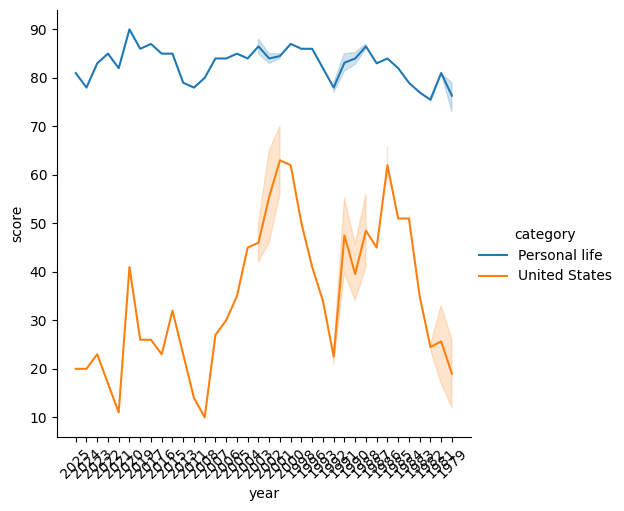

In [24]:
# Melt wide → long format
satisfaction_long = satisfaction.melt(
    id_vars="year",
    value_vars=["Personal life", "United States"],
    var_name="category",
    value_name="score"
)

# Plot with hue to separate the two lines
g = sns.relplot(
    data=satisfaction_long,
    x="year",
    y="score",
    hue="category",
    kind="line"
)

g.tick_params(axis='x', rotation=45)

### Weighted average

In [25]:
# Create function and define weights for each year of the term (most recent year = highest weight)

def weighted_term_mean(df, value_column, election_years, weights):
    results = []
    for ey in election_years:
        term_years = list(range(ey - 3, ey + 1))  # 4 years leading up to election
        term_data = df[df['year'].isin(term_years)].sort_values('year')
        
        if len(term_data) >= 1:
            w = weights[-len(term_data):]
            w_mean = np.average(term_data[f'{value_column}'].values, weights=w)
        else:
            w_mean = np.nan  # not enough data
            
        results.append({'year': ey, f'{value_column}': w_mean})
    
    return pd.DataFrame(results)

weights = [0.1, 0.2, 0.3, 0.4] # define weights



In [26]:
# Apply weight function
gini_weighted = weighted_term_mean(gini, 'gini', election_results['year'].tolist(), weights) # gini
gdp_weighted = weighted_term_mean(gdp, 'gdp', election_results['year'].tolist(), weights) # GDP
unemployment_weighted = weighted_term_mean(unemployment, 'unemployment', election_results['year'].tolist(), weights) # unemployment
inflation_weighted = weighted_term_mean(inflation, 'inflation', election_results['year'].tolist(), weights) # inflation
wage_weighted = weighted_term_mean(yearly_wage, 'wage', election_results['year'].tolist(), weights) # income
pers_weighted = weighted_term_mean(yearly_pers, 'pers', election_results['year'].tolist(), weights) # satisfaction with personal life
us_weighted = weighted_term_mean(yearly_us, 'us', election_results['year'].tolist(), weights) # satisfaction with the US


In [27]:
# check
inflation_weighted

,year,inflation
0,2024,4.485057
1,2020,1.738624
2,2016,1.011149
3,2012,2.067241
4,2008,3.375905
5,2004,2.351747
6,2000,2.551376
7,1996,2.830762
8,1992,4.044309
9,1988,3.464639


In [28]:
pers_weighted

,year,pers
0,2024,81.300000
1,2020,88.000000
2,2016,83.666667
3,2012,78.000000
4,2008,82.500000
5,2004,84.800000
6,2000,86.571429
7,1996,84.285714
8,1992,81.041667
9,1988,84.500000


### Merge data

In [29]:
# merge to single dataframe
prediction_data = pd.merge(election_results, gini_weighted, how='left', on='year') # gini
prediction_data = pd.merge(prediction_data, gdp_weighted, how = 'left', on=['year']) # GDP
prediction_data = pd.merge(prediction_data, unemployment_weighted, how = 'left', on=['year']) # unemployment
prediction_data = pd.merge(prediction_data, inflation_weighted, how = 'left', on=['year']) # inflation
prediction_data = pd.merge(prediction_data, wage_weighted, how = 'left', on=['year']) # income
prediction_data = pd.merge(prediction_data, pers_weighted, how = 'left', on=['year']) # satisaction with personal life
prediction_data = pd.merge(prediction_data, us_weighted, how = 'left', on=['year']) # satisfaction with the US


In [30]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


Sjovt at se at de her værdier er væsentligt anderledes end lineær interpolation

### Standardization and reformatting

In [31]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


In [32]:
# drop missing values
prediction_data = prediction_data.dropna()

In [33]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


In [34]:
# check types
prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party             int64
prospective 1st/2nd term for incumbent party candidate      int64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [35]:
# make ordinal
enc = OrdinalEncoder(categories=[['1', '2', '3', '4']])  # specify order
prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])

enc = OrdinalEncoder(categories=[['1', '2']])  # specify order
prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(prediction_data[['prospective 1st/2nd term for incumbent party candidate']]) #maybe we should introduce a varibale reflecting the presence of populist candidates, or something regaridn the non-incumbent candidates

/var/folders/62/r0msxcz92vb9fm2tjnbplzb80000gn/T/ipykernel_79548/4048338162.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])
/var/folders/62/r0msxcz92vb9fm2tjnbplzb80000gn/T/ipykernel_79548/4048338162.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(predi

In [36]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,0.0,0.0,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,0.0,0.0,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,2.0,0.0,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


In [37]:
# make years index
prediction_data = prediction_data.set_index('year')

In [38]:
# make years in ascending order
prediction_data = prediction_data.sort_index()

In [39]:
# check
prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
year,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,34.83,1.368685,6.5100,10.972383,323.500,76.333333,19.000000
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,37.00,3.221044,8.5800,4.943702,313.250,77.900000,38.366667
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000


SÅ ER DATAEN FÆRDIG

# Exploratory analysis

In [40]:
# standardize
scaled_prediction_data = prediction_data.copy()

cols_to_scale = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']  # standardizing predictors that are not categroical and the outcome

sc = StandardScaler()
scaled_prediction_data[cols_to_scale] = sc.fit_transform(scaled_prediction_data[cols_to_scale])

scaled_prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
year,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,-2.291322,-0.393346,0.330846,2.968804,-0.587584,-1.756298,-1.081536
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,-1.238640,1.491179,1.807505,0.523495,-1.186116,-1.303363,0.378828
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,-0.986384,1.145824,0.095436,-0.076432,-0.431381,0.604745,1.286214
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.637107,-0.944981,0.459251,0.158689,-1.098526,-0.395085,0.096567
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,0.279745,0.414211,-0.183346,-0.333541,-1.132102,0.542793,0.351179
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,0.260341,1.492255,-1.270867,-0.446863,-0.308755,1.203610,1.773121
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,0.498043,0.126423,-0.291206,-0.527835,0.221165,0.691477,1.195726
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,0.818214,-1.182503,-0.651312,-0.112423,0.051824,0.026530,-0.885480
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,0.687235,-0.928747,1.938978,-0.643234,0.235763,-1.274452,-1.458566


In [41]:
print(scaled_prediction_data.head())

      prospective conscutive term for incumbent party  \
year                                                    
1980                                              1.0   
1984                                              1.0   
1988                                              2.0   
1992                                              3.0   
1996                                              1.0   

      prospective 1st/2nd term for incumbent party candidate incumbent party  \
year                                                                           
1980                                                1.0           Democratic   
1984                                                1.0           Republican   
1988                                                0.0           Republican   
1992                                                1.0           Republican   
1996                                                1.0           Democratic   

      popular vote for incumbent party 

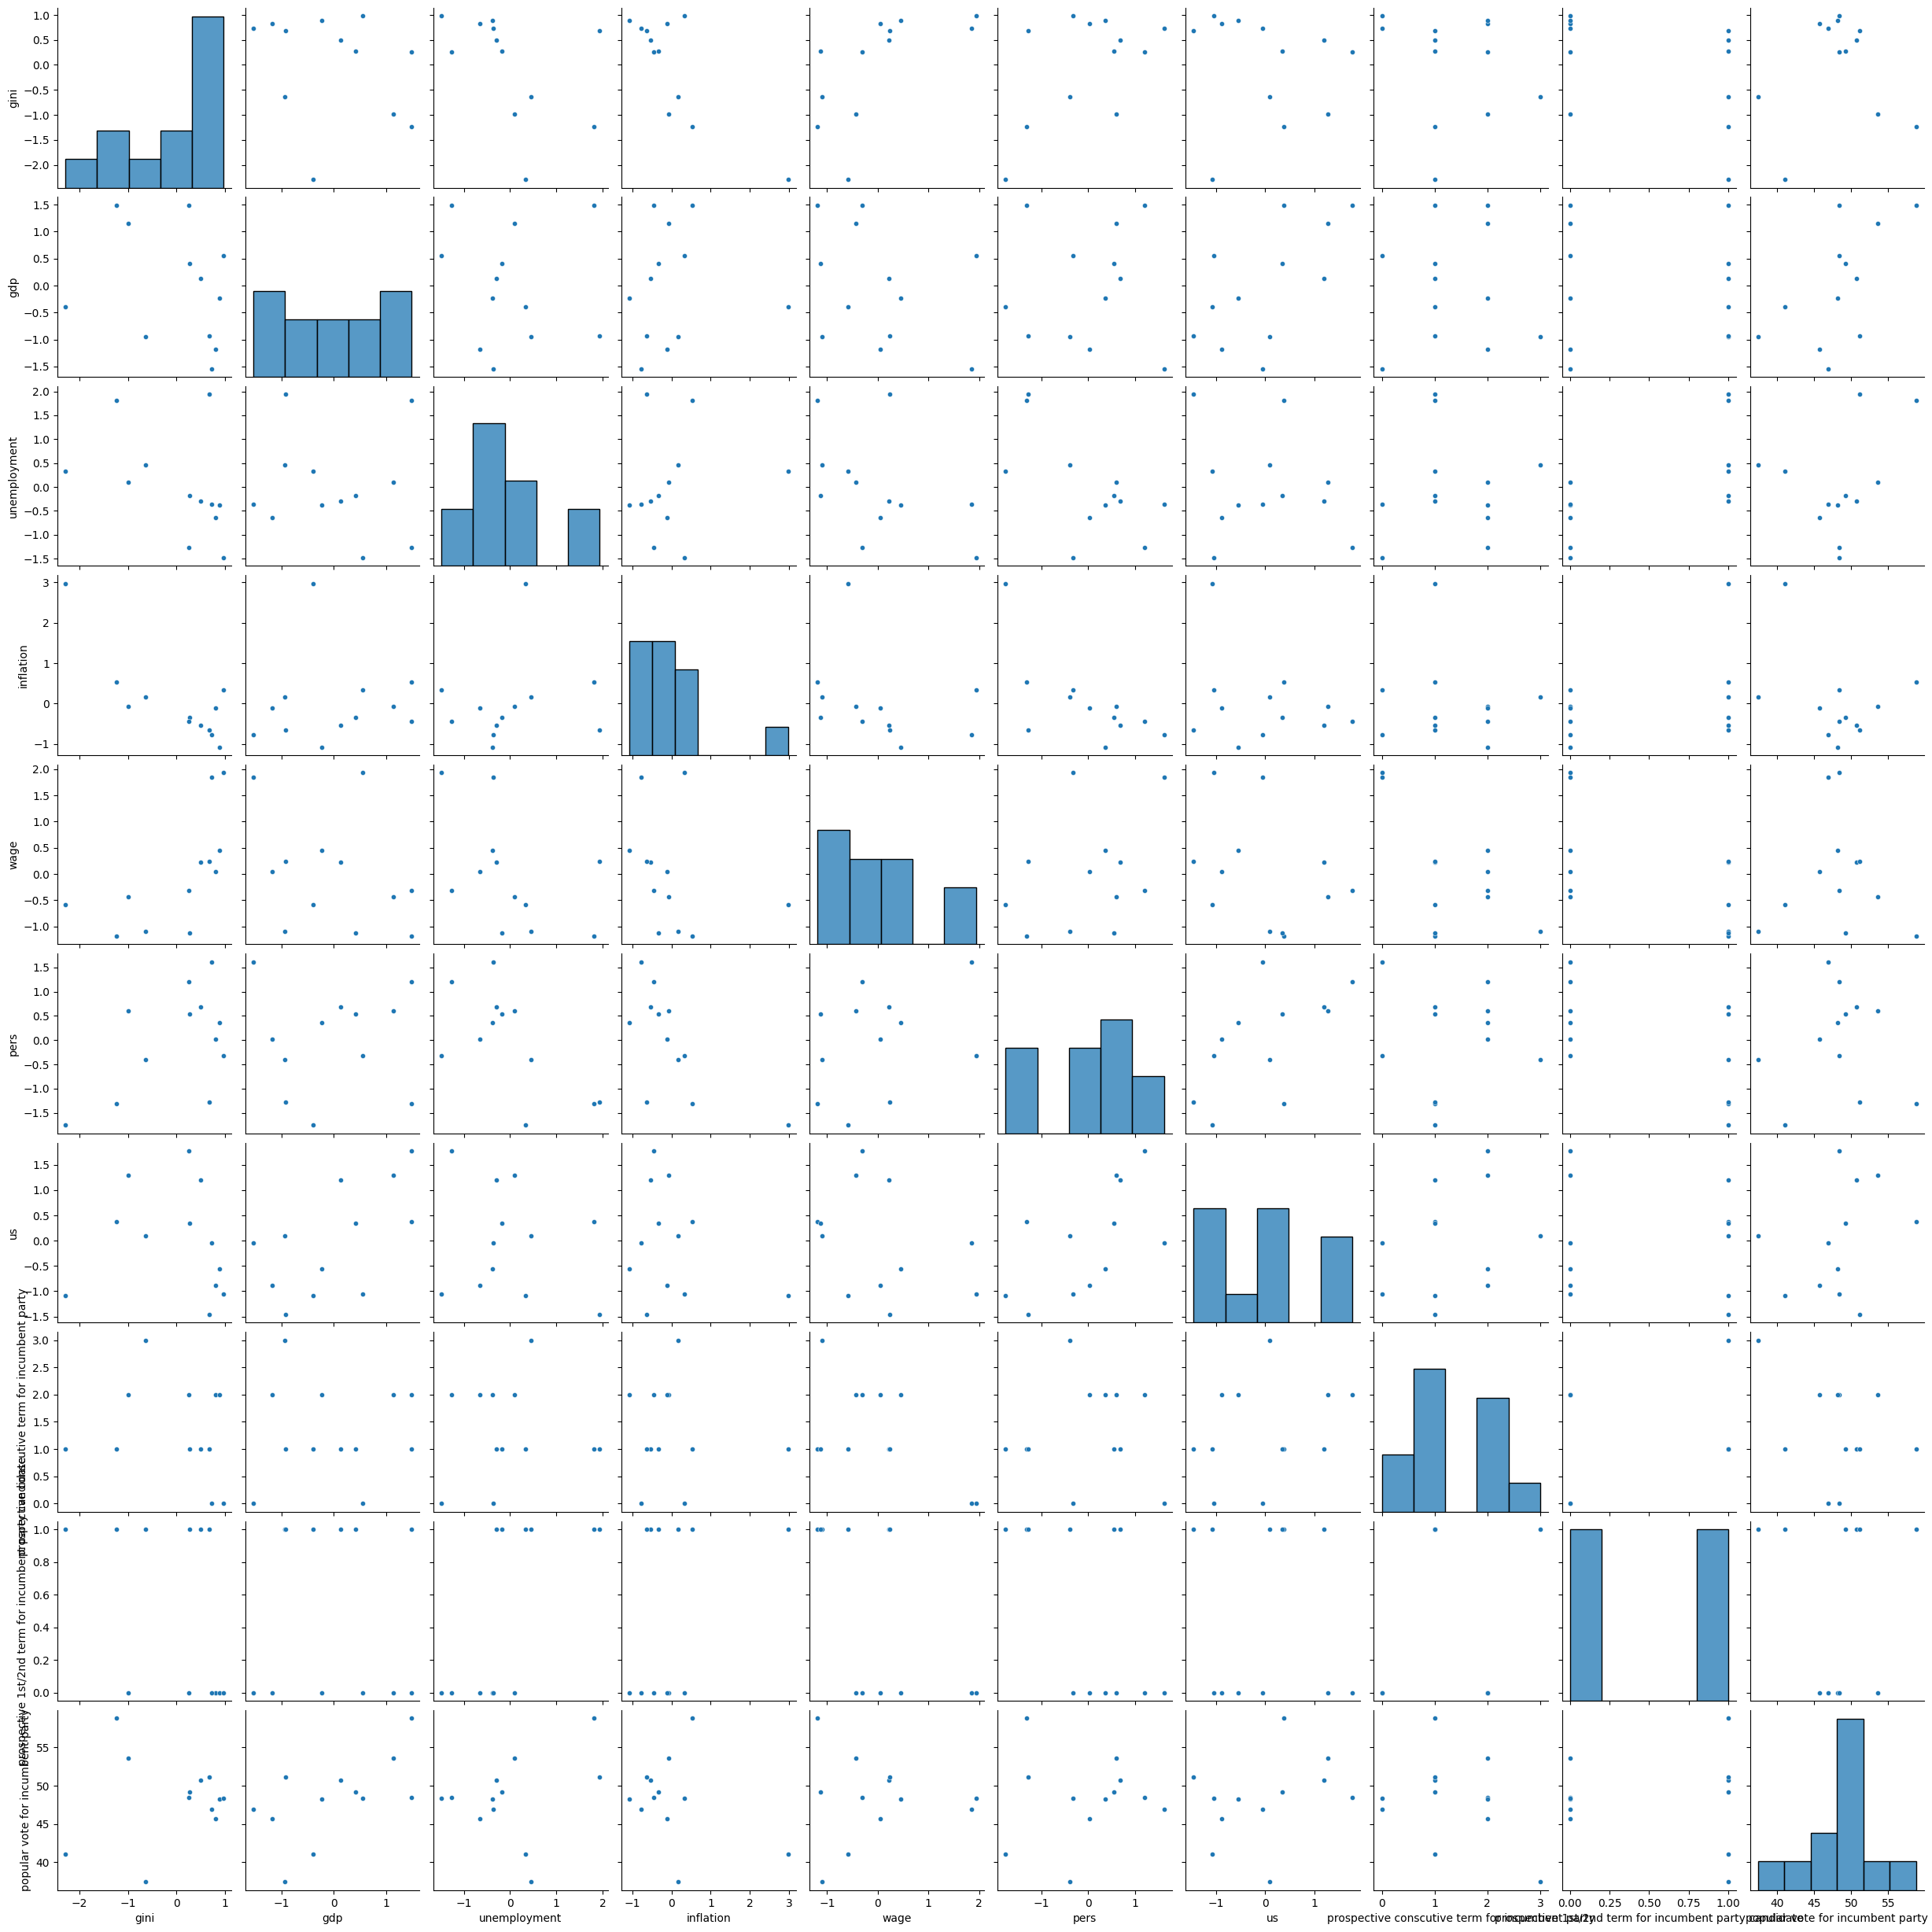

In [42]:
# plot colinearity
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate', 'popular vote for incumbent party']

sns.pairplot(scaled_prediction_data[cols], plot_kws={'alpha': 1, 's': 20})
plt.show()

In [43]:
# calculate colinearity with VIF

X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]


vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

,vif
gini,42.379545
gdp,4.013833
unemployment,22.838278
inflation,53.000320
wage,3.168965
pers,22.538819
us,11.596372
prospective conscutive term for incumbent party,4.666984
prospective 1st/2nd term for incumbent party candidate,5.643797


In [44]:
# check normality to use pearsons
for col in cols:
    stat, p = shapiro(scaled_prediction_data[col])
    print(f"{col}: p = {p:.3f} {'✅ normal' if p > 0.05 else '❌ not normal'}")

gini: p = 0.033 ❌ not normal
gdp: p = 0.522 ✅ normal
unemployment: p = 0.266 ✅ normal
inflation: p = 0.004 ❌ not normal
wage: p = 0.114 ✅ normal
pers: p = 0.751 ✅ normal
us: p = 0.606 ✅ normal
prospective conscutive term for incumbent party: p = 0.160 ✅ normal
prospective 1st/2nd term for incumbent party candidate: p = 0.000 ❌ not normal
popular vote for incumbent party: p = 0.750 ✅ normal


IndexError: index 9 is out of bounds for axis 0 with size 9

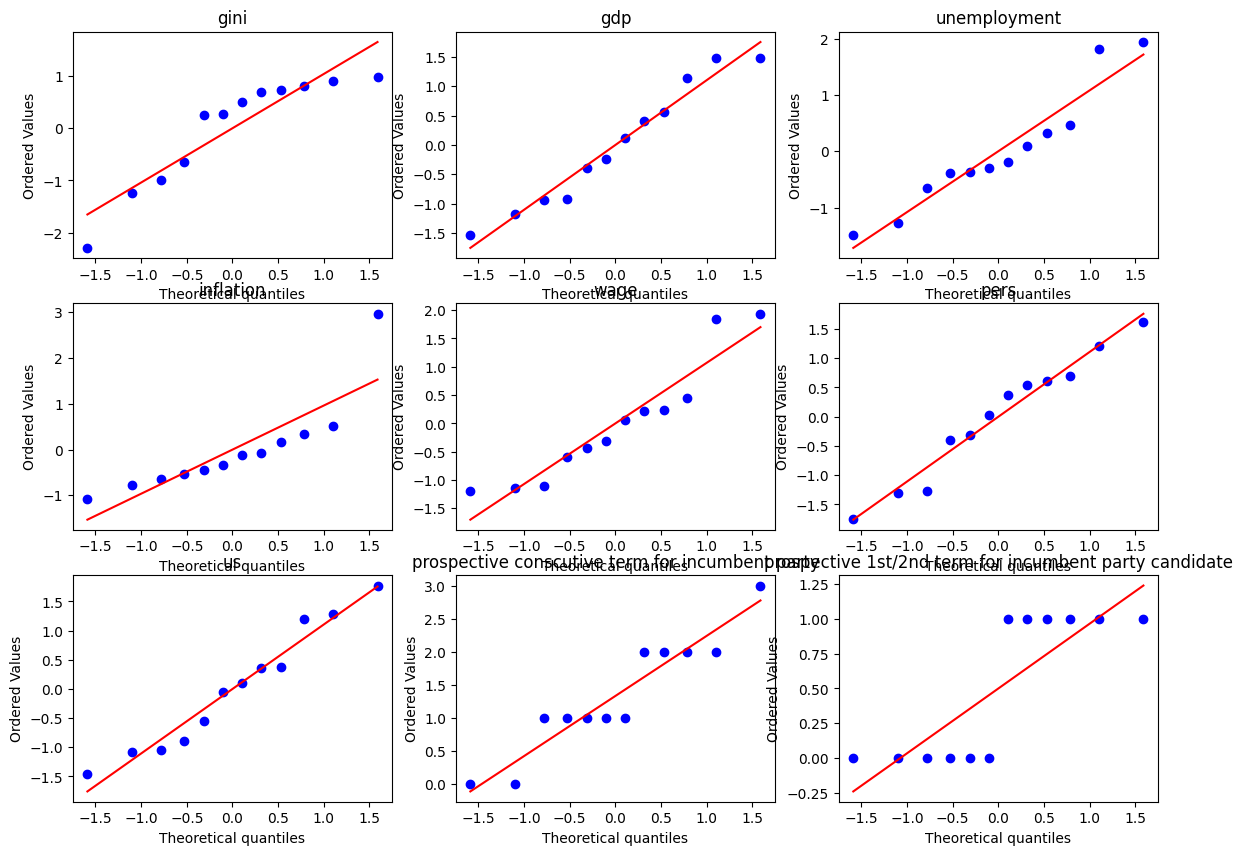

In [45]:
# check linearity to use pearsons

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    stats.probplot(scaled_prediction_data[col], plot=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

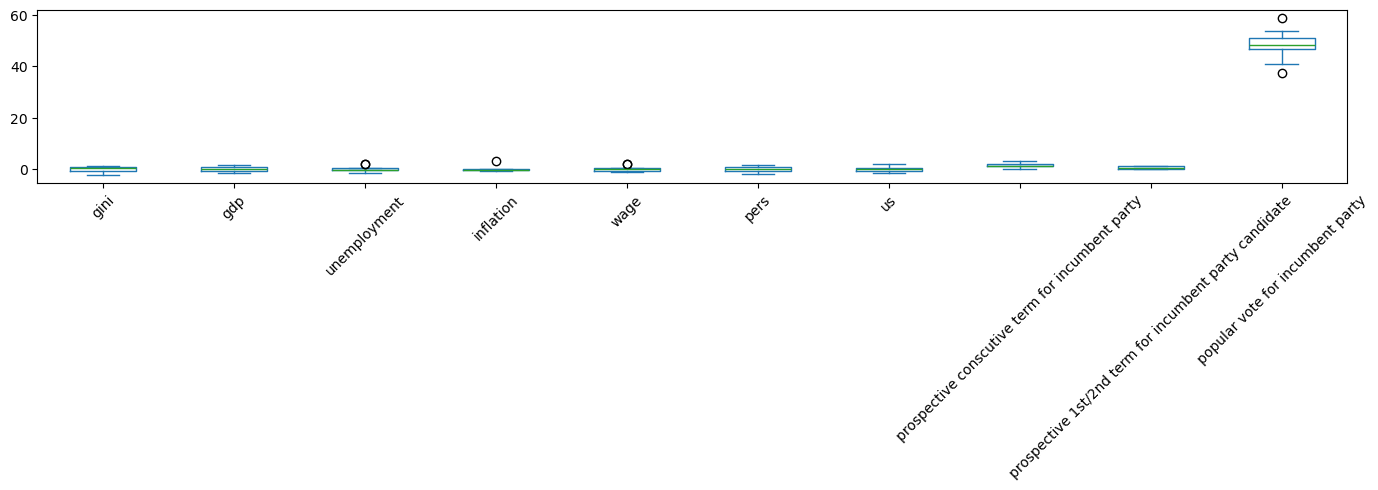

In [ ]:
# check outliers
scaled_prediction_data[cols].plot(kind='box', figsize=(14, 5), rot=45)
plt.tight_layout()
plt.show()

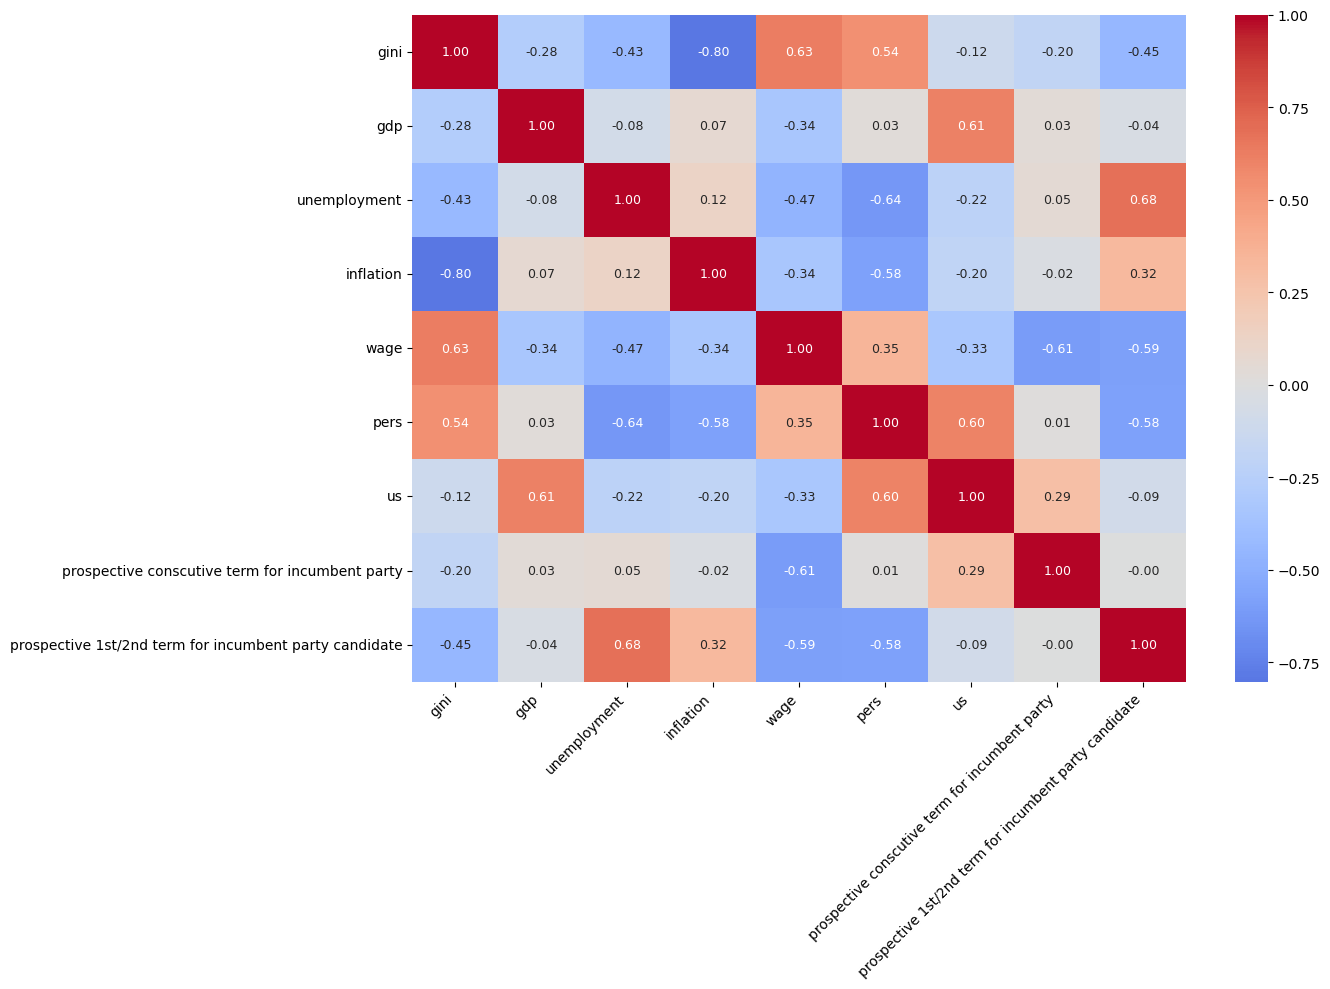

In [ ]:
# correlation matrix (pearson)
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 
        'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

corr = scaled_prediction_data[cols].corr()

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

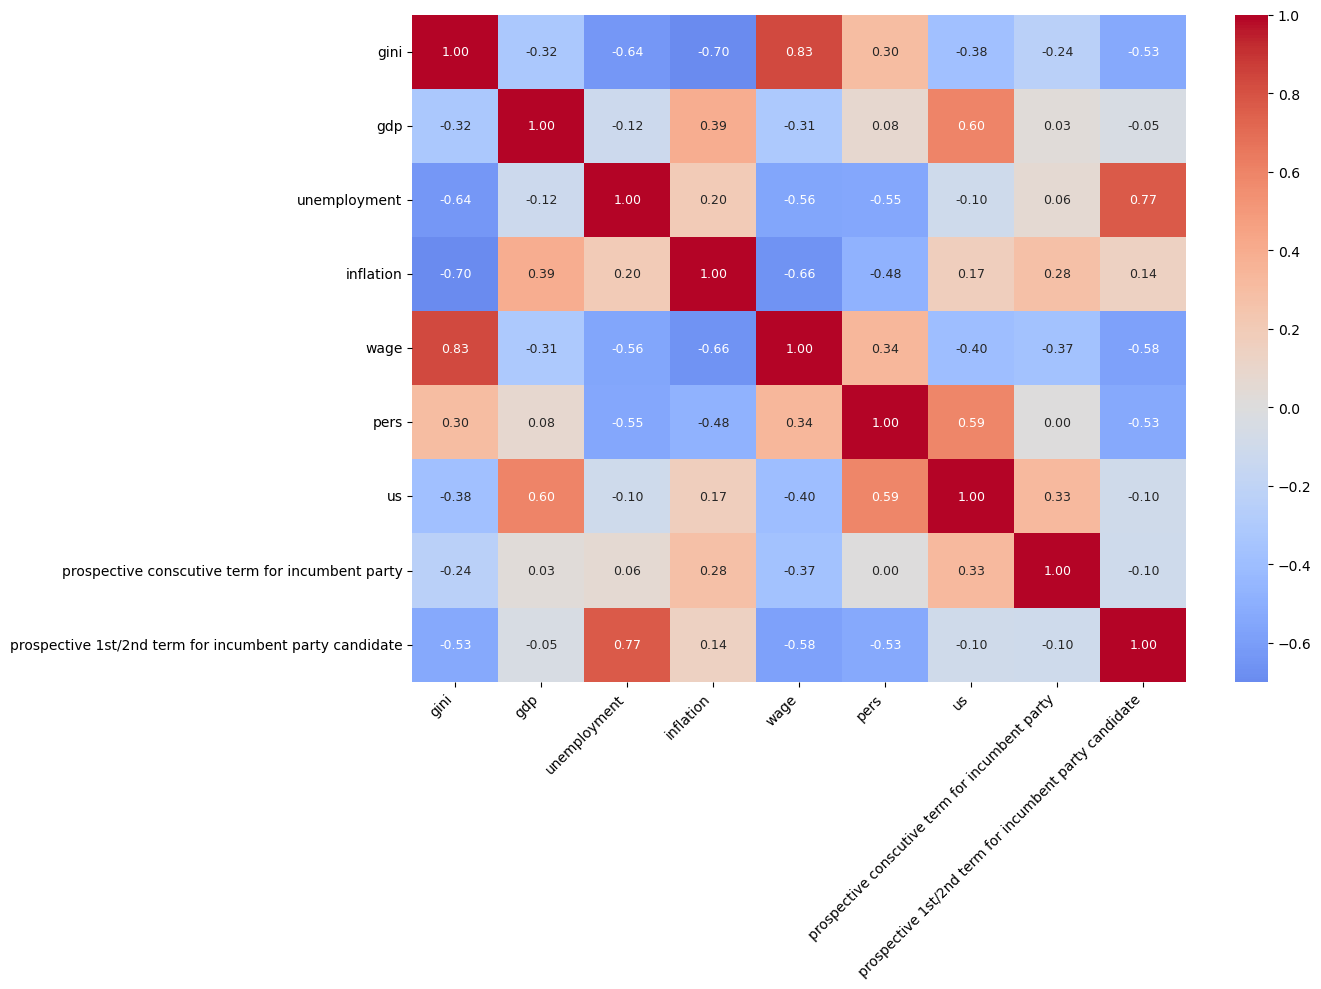

In [ ]:
# spearman correlation matrix
corr_spearman = scaled_prediction_data[cols].corr(method='spearman')
corr_spearman

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

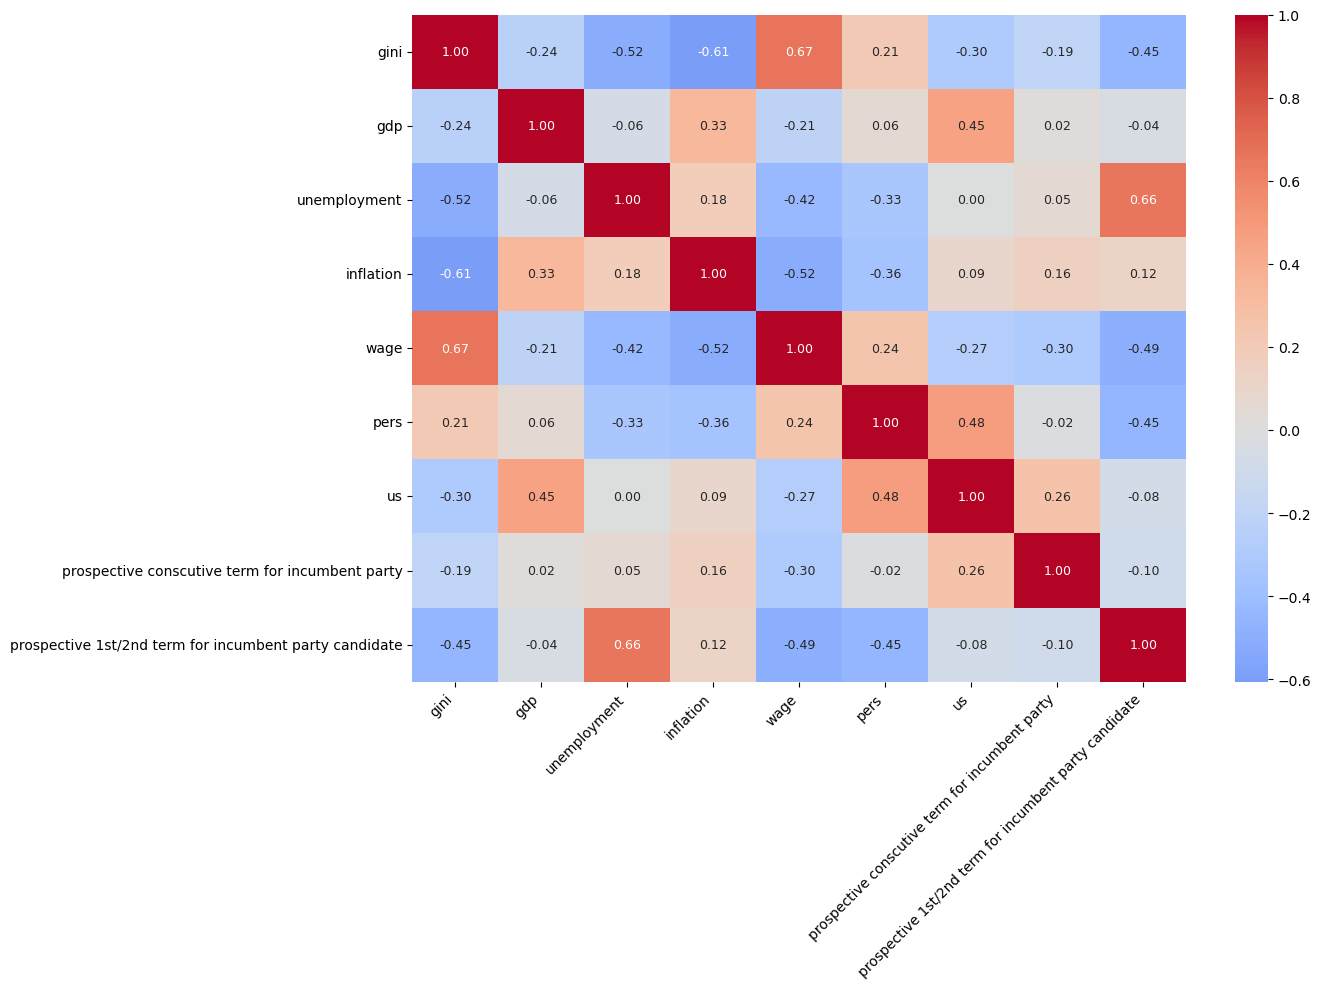

In [ ]:
# kendall correlation matrix
corr_kendall = scaled_prediction_data[cols].corr(method='kendall')
corr_kendall

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr_kendall, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

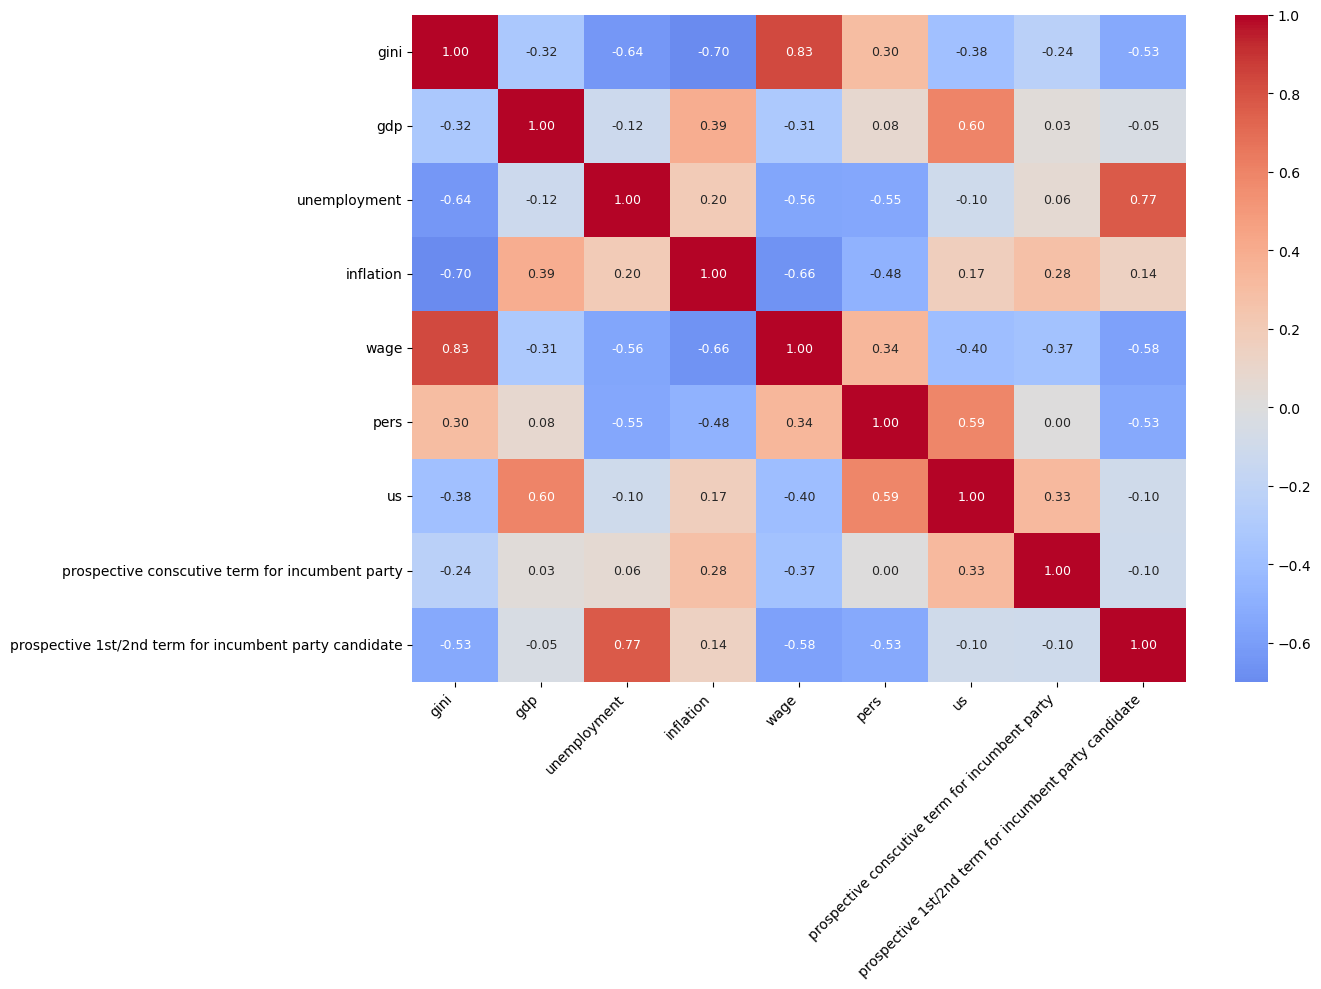

In [ ]:
# save plot
plt.figure(figsize=(14, 10))

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap_spearman.jpg", dpi=150, bbox_inches='tight')  # add this line
plt.show()

problems from the book:
1. Non-linearity of the response-predictor relationships. 
2. Correlation of error terms. 
3. Non-constant variance of error terms. 
4. Outliers. 
5. High-leverage points. 
6. Collinearity. - decreases accuracy -indentifiability problems
and thus rreduces power of the test, increases p values

## linear regression: 


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

econ_cols = ['gini', 'gdp','unemployment', 'inflation', 'wage']

# Scale first — PCA is sensitive to scale
scaler = StandardScaler()
econ_scaled = scaler.fit_transform(prediction_data[econ_cols])

# Fit PCA
pca = PCA()
pca.fit(econ_scaled)

# Check how many components to keep
print(pd.Series(pca.explained_variance_ratio_, 
                index=[f'PC{i+1}' for i in range(len(econ_cols))]))


# Keep however many components make sense (e.g. 2)
pca = PCA(n_components=3)
econ_pca = pca.fit_transform(econ_scaled)

prediction_data['econ_PC1'] = econ_pca[:, 0]
prediction_data['econ_PC2'] = econ_pca[:, 1]
prediction_data['econ_PC3'] = econ_pca[:, 2]

# Check what each component represents
loadings = pd.DataFrame(pca.components_.T, 
                         index=econ_cols, 
                         columns=['PC1', 'PC2', 'PC3'])
print(loadings)

PC1    0.504336
PC2    0.215366
PC3    0.189421
PC4    0.072405
PC5    0.018473
dtype: float64
                   PC1       PC2       PC3
gini          0.594302 -0.002216 -0.223602
gdp          -0.222065  0.815034 -0.329931
unemployment -0.351503 -0.577578 -0.501099
inflation    -0.465656 -0.005311  0.666341
wage          0.507052 -0.045728  0.382149


In [ ]:
# Null model
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = []

pipe = Pipeline([
    ('features', MS(cols)),
    ('scaler', StandardScaler()),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-3.5412102867731132


{'fit_time': array([0.01937652, 0.02006435, 0.01843762, 0.02100515, 0.01948762,
        0.01388836, 0.0163641 , 0.02137375]),
 'score_time': array([0.00424027, 0.00512981, 0.00567508, 0.00651002, 0.0060463 ,
        0.00400066, 0.00300145, 0.0057838 ]),
 'test_score': array([-2.25000000e+00, -1.60000000e-01, -6.93444444e+00, -7.52326531e+00,
        -9.00000000e+00, -5.44444444e-02, -2.40250000e+00, -5.02809917e-03])}

In [ ]:
# null model prdeicting last elections
cols = []

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = sklearn_sm(sm.OLS, MS(cols))
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions.values
}, index=Y_test.index)

print(results_df)
print(mse)

      Actual  Predicted
year                   
2016   48.20  48.433333
2020   46.86  48.433333
2024   48.34  48.433333
0.8461777777777736


In [ ]:
# all predictors model
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=6)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-114.35868078974148


{'fit_time': array([0.01099491, 0.00742579, 0.00970006, 0.01953268, 0.0130024 ,
        0.01000404]),
 'score_time': array([0.0064764 , 0.00532579, 0.00983834, 0.00599933, 0.00600147,
        0.00506091]),
 'test_score': array([ -26.3113383 ,  -51.59529122,  -65.14824705,   -4.24225515,
        -511.85408384,  -27.00086918])}

In [ ]:
# econ predictors model
X = prediction_data[['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-36.65781110914007


{'fit_time': array([0.01134562, 0.01000023, 0.01100206, 0.01567841, 0.01453376,
        0.00962496, 0.00673389, 0.00900054]),
 'score_time': array([0.00630403, 0.0046885 , 0.00968361, 0.00862789, 0.00948524,
        0.00335145, 0.00517988, 0.0049293 ]),
 'test_score': array([-37.02490245, -21.57292045, -47.03437262, -88.23863967,
        -13.8718303 ,  -0.51173758, -79.39023978,  -5.61784602])}

In [ ]:
X = prediction_data[ ['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.858
Model:                                          OLS   Adj. R-squared:                  0.740
Method:                               Least Squares   F-statistic:                     7.255
Date:                              Mon, 25 May 2026   Prob (F-statistic):             0.0159
Time:                                      13:31:00   Log-Likelihood:                -25.264
No. Observations:                                12   AIC:                             62.53
Df Residuals:                                     6   BIC:                             65.44
Df Model:                                         5                                         
Covariance Type:                          nonrobust                                         
                                                             coef    s

c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [47]:
# well-being predictors model
X = prediction_data[['pers','prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-886.6907032320944


{'fit_time': array([0.01078773, 0.00118518, 0.00090504, 0.00099206, 0.00097895,
        0.00085616, 0.00172424, 0.00125194]),
 'score_time': array([0.00146627, 0.0004468 , 0.00039411, 0.00042415, 0.00039411,
        0.000386  , 0.00101686, 0.00045228]),
 'test_score': array([-6.74904699e+03, -3.38554441e+01, -9.01432469e-02, -2.32121775e+01,
        -4.20335488e+00, -6.79144254e-01, -2.55959204e+02, -2.64791678e+01])}

In [ ]:
X = prediction_data[['pers',
                      'prospective conscutive term for incumbent party', 
                      'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.110
Model:                                          OLS   Adj. R-squared:                 -0.224
Method:                               Least Squares   F-statistic:                    0.3296
Date:                              Mon, 25 May 2026   Prob (F-statistic):              0.804
Time:                                      13:31:00   Log-Likelihood:                -36.280
No. Observations:                                12   AIC:                             80.56
Df Residuals:                                     8   BIC:                             82.50
Df Model:                                         3                                         
Covariance Type:                          nonrobust                                         
                                                             coef    s

c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [48]:
# all predictors model prdeicting last elections
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

      Actual  Predicted
year                   
2016   48.20  47.495209
2020   46.86  48.472664
2024   48.34  51.436961
4.229528139747047


In [49]:
# get it the uncertainty

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 
        'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# ── Step 1: collect CV residuals from the training data ──────────────────────
tss = TimeSeriesSplit(n_splits=6, test_size=1)
residuals = []

for train_idx, test_idx in tss.split(X_train):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_test  = X_train.iloc[test_idx]
    Y_fold_train = Y_train.iloc[train_idx]
    Y_fold_test  = Y_train.iloc[test_idx]

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_test_scaled  = fold_scaler.transform(X_fold_test)

    fold_model = Lasso(alpha=1, fit_intercept=True)
    fold_model.fit(X_fold_train_scaled, Y_fold_train)
    fold_pred = fold_model.predict(X_fold_test_scaled)

    residuals.append(float(Y_fold_test) - float(fold_pred))

residuals = np.array(residuals)
print("CV residuals:", residuals)
print("Mean error:", round(residuals.mean(), 2))   # systematic bias?
print("Std of errors:", round(residuals.std(), 2)) # typical spread

# ── Step 2: fit final model on all training data ─────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Lasso(alpha=1, fit_intercept=True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

# ── Step 3: build intervals using ±2 SD of residuals ─────────────────────────
margin = 2 * residuals.std()
lower  = predictions - margin
upper  = predictions + margin

# ── Step 4: results ───────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Actual':    Y_test.values,
    'Predicted': predictions,
    'Lower':     lower,
    'Upper':     upper,
    'Contains actual': (Y_test.values >= lower) & (Y_test.values <= upper)
}, index=Y_test.index)

mse = np.mean((Y_test.values - predictions)**2)

print(results_df)
print("MSE:", round(mse, 3))

/var/folders/62/r0msxcz92vb9fm2tjnbplzb80000gn/T/ipykernel_79548/398401291.py:32: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  residuals.append(float(Y_fold_test) - float(fold_pred))


TypeError: only 0-dimensional arrays can be converted to Python scalars

In [50]:
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 
        'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# ── Step 1: collect CV residuals from the training data ──────────────────────
tss = TimeSeriesSplit(n_splits=6, test_size=1)
residuals = []

for train_idx, test_idx in tss.split(X_train):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_test  = X_train.iloc[test_idx]
    Y_fold_train = Y_train.iloc[train_idx]
    Y_fold_test  = Y_train.iloc[test_idx]

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_test_scaled  = fold_scaler.transform(X_fold_test)

    fold_model = Lasso(alpha=1, fit_intercept=True)
    fold_model.fit(X_fold_train_scaled, Y_fold_train)
    fold_pred = fold_model.predict(X_fold_test_scaled)

    residuals.append(float(Y_fold_test.iloc[0]) - float(fold_pred[0]))

residuals = np.array(residuals)
print("CV residuals:", residuals)
print("Mean error:", round(residuals.mean(), 2))
print("Std of errors:", round(residuals.std(), 2))

# ── Step 2: fit final model on all training data ─────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Lasso(alpha=1, fit_intercept=True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

# ── Step 3: build intervals using ±2 SD of residuals ─────────────────────────
margin = 2 * residuals.std()
lower  = predictions - margin
upper  = predictions + margin

# ── Step 4: results ───────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Actual':           Y_test.values,
    'Predicted':        predictions,
    'Lower':            lower,
    'Upper':            upper,
    'Contains actual':  (Y_test.values >= lower) & (Y_test.values <= upper)
}, index=Y_test.index)

mse = np.mean((Y_test.values - predictions)**2)

print(results_df)
prin

CV residuals: [-0.73103978  1.24279915 -8.21027752  5.66508781  6.54850092  3.38889735]
Mean error: 1.32
Std of errors: 4.93
      Actual  Predicted      Lower      Upper  Contains actual
year                                                          
2016   48.20  47.495209  37.645126  57.345293             True
2020   46.86  48.472664  38.622580  58.322747             True
2024   48.34  51.436961  41.586878  61.287045             True


NameError: name 'prin' is not defined

In [ ]:
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 
        'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# ── Step 1: collect CV residuals from the training data ──────────────────────
tss = TimeSeriesSplit(n_splits=8, test_size=1)
residuals = []

for train_idx, test_idx in tss.split(X_train):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_test  = X_train.iloc[test_idx]
    Y_fold_train = Y_train.iloc[train_idx]
    Y_fold_test  = Y_train.iloc[test_idx]

    # skip fold if any NaN values present
    if X_fold_train.isnull().any().any() or X_fold_test.isnull().any().any():
        print(f"Skipping fold due to NaN values")
        continue

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_test_scaled  = fold_scaler.transform(X_fold_test)

    fold_model = Lasso(alpha=1, fit_intercept=True)
    fold_model.fit(X_fold_train_scaled, Y_fold_train)
    fold_pred = fold_model.predict(X_fold_test_scaled)

    residuals.append(float(Y_fold_test.iloc[0]) - float(fold_pred[0]))

print(f"Residuals collected from {len(residuals)} folds")
residuals = np.array(residuals)
print("CV residuals:", residuals)
print("Mean error:", round(residuals.mean(), 2))
print("Std of errors:", round(residuals.std(), 2))

# ── Step 2: fit final model on all training data ─────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Lasso(alpha=1, fit_intercept=True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

# ── Step 3: build intervals using ±2 SD of residuals ─────────────────────────
margin = 2 * residuals.std()
lower  = predictions - margin
upper  = predictions + margin

# ── Step 4: results ───────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Actual':           Y_test.values,
    'Predicted':        predictions,
    'Lower':            lower,
    'Upper':            upper,
    'Contains actual':  (Y_test.values >= lower) & (Y_test.values <= upper)
}, index=Y_test.index)

mse = np.mean((Y_test.values - predictions)**2)

print(results_df)
print("MSE:", round(mse, 3))

Skipping fold due to NaN values
Skipping fold due to NaN values
Residuals collected from 6 folds
CV residuals: [  0.41789322  -0.11886117 -11.64233888  10.25555728   9.48150716
  -7.90428927]
Mean error: 0.08
Std of errors: 8.1


ValueError: Input X contains NaN.
Lasso does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
for fold_num, (train_idx, test_idx) in enumerate(tss.split(X_train)):
    print(f"Fold {fold_num+1}: train size = {len(train_idx)}, test year = {X_train.index[test_idx[0]]}")

    print(X_train.index)
print(type(X_train.index[0]))

Fold 1: train size = 6, test year = 6
RangeIndex(start=0, stop=14, step=1)
Fold 2: train size = 7, test year = 7
RangeIndex(start=0, stop=14, step=1)
Fold 3: train size = 8, test year = 8
RangeIndex(start=0, stop=14, step=1)
Fold 4: train size = 9, test year = 9
RangeIndex(start=0, stop=14, step=1)
Fold 5: train size = 10, test year = 10
RangeIndex(start=0, stop=14, step=1)
Fold 6: train size = 11, test year = 11
RangeIndex(start=0, stop=14, step=1)
Fold 7: train size = 12, test year = 12
RangeIndex(start=0, stop=14, step=1)
Fold 8: train size = 13, test year = 13
RangeIndex(start=0, stop=14, step=1)
<class 'int'>


In [46]:
print(X_train.index)
print(type(X_train.index[0]))

NameError: name 'X_train' is not defined

In [ ]:
X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

print(X.index)  # should show election years

RangeIndex(start=0, stop=17, step=1)


In [ ]:
for col in X_fold_train.columns:
    if X_fold_train[col].std() == 0:
        print(f"Fold {fold_num+1}: zero variance in column '{col}'")

In [ ]:
residuals = []

for fold_num, (train_idx, test_idx) in enumerate(tss.split(X_train)):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_test  = X_train.iloc[test_idx]
    Y_fold_train = Y_train.iloc[train_idx]
    Y_fold_test  = Y_train.iloc[test_idx]

    # check which column has zero variance
    for col in X_fold_train.columns:
        if X_fold_train[col].std() == 0:
            print(f"Fold {fold_num+1}: zero variance in column '{col}'")

    # skip fold if any NaN values present
    if X_fold_train.isnull().any().any() or X_fold_test.isnull().any().any():
        print(f"Skipping fold {fold_num+1} due to NaN values")
        continue

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_test_scaled  = fold_scaler.transform(X_fold_test)

    fold_model = Lasso(alpha=1, fit_intercept=True)
    fold_model.fit(X_fold_train_scaled, Y_fold_train)
    fold_pred = fold_model.predict(X_fold_test_scaled)

    residuals.append(float(Y_fold_test.iloc[0]) - float(fold_pred[0]))

Skipping fold 7 due to NaN values
Skipping fold 8 due to NaN values


In [ ]:
for fold_num, (train_idx, test_idx) in enumerate(tss.split(X_train)):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_test  = X_train.iloc[test_idx]
    
    print(f"Fold {fold_num+1}: train size = {len(train_idx)}, test size = {len(test_idx)}")
    print(f"  NaN in train: {X_fold_train.isnull().sum().sum()}")
    print(f"  NaN in test: {X_fold_test.isnull().sum().sum()}")
    if X_fold_test.isnull().any().any():
        print(f"  Columns with NaN in test: {X_fold_test.columns[X_fold_test.isnull().any()].tolist()}")

Fold 1: train size = 6, test size = 1
  NaN in train: 0
  NaN in test: 0
Fold 2: train size = 7, test size = 1
  NaN in train: 0
  NaN in test: 0
Fold 3: train size = 8, test size = 1
  NaN in train: 0
  NaN in test: 0
Fold 4: train size = 9, test size = 1
  NaN in train: 0
  NaN in test: 0
Fold 5: train size = 10, test size = 1
  NaN in train: 0
  NaN in test: 0
Fold 6: train size = 11, test size = 1
  NaN in train: 0
  NaN in test: 0
Fold 7: train size = 12, test size = 1
  NaN in train: 0
  NaN in test: 3
  Columns with NaN in test: ['wage', 'pers', 'us']
Fold 8: train size = 13, test size = 1
  NaN in train: 3
  NaN in test: 3
  Columns with NaN in test: ['wage', 'pers', 'us']


In [ ]:
print(len(X_train))

14


In [61]:
print(len(prediction_data))
print(prediction_data.index.tolist())

17
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


## NOW LASSO

In [ ]:
# calculate colinearity with VIF

X = scaled_prediction_data[['econ_PC1','econ_PC2' 'econ_PC3']]


vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

KeyError: "None of [Index(['econ_PC1', 'econ_PC2econ_PC3'], dtype='object')] are in the [columns]"

In [ ]:
# calculate colinearity with VIF

X = scaled_prediction_data[['pers', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]


vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

,vif
pers,1.365766
prospective conscutive term for incumbent party,1.759763
prospective 1st/2nd term for incumbent party candidate,2.119218


In [ ]:
# calculate colinearity with VIF

X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

,vif
gini,6.993823
gdp,1.533068
unemployment,2.888994
inflation,4.959695
wage,2.330526
prospective conscutive term for incumbent party,2.282266
prospective 1st/2nd term for incumbent party candidate,2.701747


In [ ]:
# calculate colinearity with VIF

X = scaled_prediction_data[['gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

,vif
gdp,1.275992
unemployment,2.029983
inflation,1.268854
wage,2.127011
prospective conscutive term for incumbent party,2.141634
prospective 1st/2nd term for incumbent party candidate,2.515085


In [ ]:
# all predictors model_no interacitons
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 5, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-4.424568015543055


{'fit_time': array([0.0074687 , 0.00857925, 0.00920892, 0.00896192, 0.0078907 ,
        0.01119041, 0.01429462, 0.00968719]),
 'score_time': array([0.00518775, 0.00309396, 0.00550699, 0.00399065, 0.00338483,
        0.00521922, 0.00348473, 0.00500226]),
 'test_score': array([-1.37203586e+00, -1.00746674e+01, -1.06048812e+01, -1.88298712e+00,
        -9.00000000e+00, -5.44444444e-02, -2.40250000e+00, -5.02809917e-03])}

In [ ]:
# all predictors model - all interactions
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-14.885081657530385


{'fit_time': array([0.00594473, 0.00687099, 0.00500321, 0.00600433, 0.00500464,
        0.00625849, 0.006001  , 0.00652671]),
 'score_time': array([0.00499868, 0.01972365, 0.00199747, 0.00304461, 0.00151038,
        0.00400019, 0.00300074, 0.00300121]),
 'test_score': array([ -0.88949328, -52.64501467, -24.74724028, -18.18924422,
        -11.54325381,  -5.26173276,  -1.64127843,  -4.1633958 ])}

In [ ]:
# econ predictors model_no interactions
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-21.994889126307804


{'fit_time': array([0.01161456, 0.01126766, 0.01226139, 0.00677872, 0.00872135,
        0.00599265, 0.0064218 , 0.02315259]),
 'score_time': array([0.0045166 , 0.00499916, 0.00448775, 0.00452542, 0.00346351,
        0.00531316, 0.00406814, 0.00800133]),
 'test_score': array([ -1.54454973, -67.40865699, -32.09321992, -43.08762941,
        -16.22868519,  -0.96423191,  -5.53172661,  -9.10041325])}

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0    0.000000
1    2.367657
2    0.911968
3   -0.920983
4    0.000000
5   -0.867989
6   -0.000000
dtype: float64
intercept: 48.275000000000006


In [ ]:
# econ predictors model _all nteractions
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-13.623510261697566


{'fit_time': array([0.00476289, 0.00611854, 0.00542998, 0.00655246, 0.00357533,
        0.00302386, 0.00319195, 0.00528646]),
 'score_time': array([0.00252628, 0.00303721, 0.00199986, 0.00222278, 0.00202417,
        0.00118065, 0.00349259, 0.00407124]),
 'test_score': array([ -0.88891964, -52.64501467, -24.74724   ,  -8.08459767,
        -11.54326238,  -5.27441479,  -1.64123737,  -4.16339557])}

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0     0.000000
1     0.000000
2     0.000000
3     0.000000
4    -0.000000
5     0.000000
6    -0.000000
7    -0.000000
8     0.000000
9     0.358701
10   -0.000000
11    0.000000
12   -0.000000
13   -0.000000
14    2.852203
15   -0.000000
16    0.000000
17    0.000000
18    0.000000
19   -0.000000
20    0.000000
21   -0.000000
22    0.000000
23   -0.000000
24   -1.275313
25   -0.000000
26   -0.000000
27   -0.000000
28   -1.001043
dtype: float64
intercept: 48.275000000000006


In [ ]:
# econ predictors model - gini _all nteractions
X = prediction_data[['gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']


pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-21.99479232072766


{'fit_time': array([0.00982928, 0.00959635, 0.01114798, 0.00924802, 0.01260161,
        0.009763  , 0.00956559, 0.00682282]),
 'score_time': array([0.00603366, 0.00757408, 0.00548768, 0.00544739, 0.00642371,
        0.00422645, 0.00378227, 0.0020051 ]),
 'test_score': array([ -1.54454973, -67.40865699, -32.09321992, -43.08716716,
        -16.228373  ,  -0.96423191,  -5.53172661,  -9.10041325])}

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0    2.367657
1    0.911968
2   -0.920983
3    0.000000
4   -0.867989
5   -0.000000
dtype: float64
intercept: 48.275000000000006


In [ ]:
# econ predictors model - gini _all nteractions
X = prediction_data[['econ_PC1', 'econ_PC2', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['econ_PC1', 'econ_PC2'
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

#X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 5, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-5.031713131708999


{'fit_time': array([0.00803256, 0.00707603, 0.00656414, 0.01036596, 0.00550461,
        0.0087235 , 0.00669527, 0.00462341]),
 'score_time': array([0.00561142, 0.00300288, 0.00339222, 0.00408506, 0.00329852,
        0.00201154, 0.00350714, 0.00300908]),
 'test_score': array([-2.47609650e-01, -1.40864131e+01, -6.93444444e+00, -7.52326531e+00,
        -9.00000000e+00, -5.44444444e-02, -2.40250000e+00, -5.02809917e-03])}

In [ ]:
# econ predictors model - gini _all nteractions
X = prediction_data[['gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-13.246817944083872


{'fit_time': array([0.00500369, 0.00364423, 0.00441694, 0.00407243, 0.00336099,
        0.00302124, 0.00468564, 0.00243831]),
 'score_time': array([0.00225163, 0.00230026, 0.00100946, 0.00364447, 0.00215793,
        0.00307226, 0.00110865, 0.00100231]),
 'test_score': array([ -2.82743514, -46.51010354, -24.74643444,  -8.08453598,
        -11.54318192,  -5.27433315,  -1.88792075,  -5.10059864])}

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0     0.000000
1     0.000000
2     0.000000
3    -0.000000
4     0.000000
5    -0.000000
6    -0.000000
7     2.887152
8    -0.000000
9     0.000000
10    0.000000
11    0.000000
12   -0.000000
13    0.234618
14   -0.000000
15    0.000000
16   -0.000000
17   -1.325152
18   -0.000000
19   -0.000000
20   -0.000000
21   -0.923349
dtype: float64
intercept: 48.275000000000006


In [ ]:
# econ predictors model - gini _all nteractions
X = prediction_data[['pers', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-13.260680375876065


{'fit_time': array([0.00416493, 0.00520277, 0.00355625, 0.00736523, 0.00299931,
        0.00300026, 0.0037756 , 0.00770116]),
 'score_time': array([0.00222898, 0.00101876, 0.00100279, 0.00300097, 0.00200129,
        0.00256634, 0.00208807, 0.00303626]),
 'test_score': array([-1.56668220e-06, -2.25658549e+01, -2.72688417e+00, -2.45473584e+01,
        -3.08154915e+00, -5.60102234e-01, -4.79206541e+01, -4.68303854e+00])}

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0    0.000000
1   -0.000000
2   -0.276340
3    0.000000
4   -0.000000
5    0.000000
6   -1.168662
dtype: float64
intercept: 48.275000000000006


In [ ]:
# econ predictors model - gini _all nteractions
X = prediction_data[['pers', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-25.274444192964744


{'fit_time': array([0.00960588, 0.01208258, 0.01151228, 0.02332377, 0.00626516,
        0.00641298, 0.00817585, 0.01006842]),
 'score_time': array([0.00400019, 0.01521945, 0.00599957, 0.00762582, 0.00399995,
        0.00315738, 0.00424695, 0.00699782]),
 'test_score': array([-110.23297095,  -10.24      ,   -1.70900806,  -13.8299284 ,
          -2.79687316,   -0.15010641,  -59.79901003,   -3.43765653])}

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0    0.000000
1   -0.725822
2   -0.000000
dtype: float64
intercept: 48.275000000000006


In [ ]:
prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us,econ_PC1,econ_PC2,econ_PC3
year,,,,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,34.83,1.368685,6.5100,13.549202,323.500,76.333333,19.000000,-3.159526,-0.496511,2.356618
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,37.00,3.221044,8.5800,4.300535,313.250,77.900000,38.366667,-2.383181,0.227467,-1.460774
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000,-1.138560,0.900155,-0.304875
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457,-0.775005,-0.982519,-0.356278
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000,-0.308407,0.496089,-0.721574
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143,0.173350,1.964486,-0.117354
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000,0.647544,0.261900,-0.158926
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000,0.994362,-0.591890,0.567264
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,78.000000,14.000000,0.309260,-1.886248,-1.095962


In [ ]:
# all predictors model prdeicting last elections
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Fix 1: keep as DataFrame, Fix 2: remove .astype(int)
poly = PolynomialFeatures(interaction_only=True, include_bias=False)
X_poly = pd.DataFrame(poly.fit_transform(X), 
                       columns=poly.get_feature_names_out(cols),
                       index=X.index)  # ← preserve index for iloc to work

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X_poly[:-3], X_poly[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

print(pipe.named_steps['model'].coef_)

      Actual  Predicted
year                   
2016   48.20  50.493847
2020   46.86  49.039988
2024   48.34  52.049097
7.923827212741263
[ 0.         -0.72582199 -0.        ]


In [ ]:
feature_names = poly.get_feature_names_out(cols)
non_zero = pd.Series(model.coef_, index=feature_names)
print(non_zero[non_zero != 0])

gdp unemployment                                                                                          2.917091
unemployment wage                                                                                         0.155663
unemployment pers                                                                                         0.036332
inflation prospective conscutive term for incumbent party                                                -2.019239
prospective conscutive term for incumbent party prospective 1st/2nd term for incumbent party candidate   -1.411972
dtype: float64


In [ ]:
'''# Split: everything except last 2 = train, last 2 = test - giver andre resultater end den over
X = prediction_data.drop(columns=['popular vote for incumbent party'])
Y = prediction_data['popular vote for incumbent party']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = Lasso(alpha = 1)

pipe = Pipeline([
    ('features', ms),
    ('scaler', StandardScaler()),
    ('model', model)
])

pipe.fit(X_train, Y_train)    
predictions = pipe.predict(X_test)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)

print(pipe.named_steps['model'].coef_)'''

"# Split: everything except last 2 = train, last 2 = test - giver andre resultater end den over\nX = prediction_data.drop(columns=['popular vote for incumbent party'])\nY = prediction_data['popular vote for incumbent party']\n\nX_train, X_test = X.iloc[:-3], X.iloc[-3:]\nY_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]\n\n# Fit on training data, predict on last 2\nmodel = Lasso(alpha = 1)\n\npipe = Pipeline([\n    ('features', ms),\n    ('scaler', StandardScaler()),\n    ('model', model)\n])\n\npipe.fit(X_train, Y_train)    \npredictions = pipe.predict(X_test)\n\n# Compare predictions vs actuals\nresults_df = pd.DataFrame({\n    'Actual': Y_test.values,\n    'Predicted': predictions\n}, index=Y_test.index)\n\nprint(results_df)\n\nprint(pipe.named_steps['model'].coef_)"

## BART

In [ ]:
def bart_cv(cols, name, burnin = 5, ndraw = 15):
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    model = BART(random_state =0, burnin = burnin, ndraw = ndraw)  

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    tss = TimeSeriesSplit(n_splits=8, test_size=1)

    # Pass the full dataset — MS handles column selection inside the pipeline
    cv_results = cross_validate(pipe, X, Y, cv=tss,  scoring='neg_mean_squared_error')
    cv_err = np.mean(cv_results['test_score'])
    cv_df = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})

    print(cv_err)
    print(cv_results)
    return(cv_df)


In [ ]:
def bart_pred(cols, name, burnin = 5, ndraw = 15, n_elections = 3):
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    # split the last n elections for test
    X_train, X_test = X.iloc[:-n_elections], X.iloc[-n_elections:]
    Y_train, Y_test = Y.iloc[:-n_elections], Y.iloc[-n_elections:]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
    X_test_scaled = scaler.transform(X_test)         # transform test with train's params

    # Fit on training data, predict on last 2
    model = BART(random_state = 0, burnin= burnin, ndraw = ndraw, num_trees=200)
    model.fit(X_train_scaled, Y_train)
    predictions = model.predict(X_test_scaled.astype(np.float32))

    mse = np.mean((Y_test - predictions)**2)

    var_inclusion = pd.Series(model. variable_inclusion_ .mean (0),  index=X.columns) 
    print(var_inclusion)
    var_df = pd.DataFrame({'predictor': var_inclusion.index, f'{name}_inclusion': var_inclusion.values})

    # Compare predictions vs actuals
    results_df = pd.DataFrame({
        'actual': Y_test.values,
        f'{name}': predictions
    }, index=Y_test.index)
    print(results_df)
    print(mse)
    return(results_df, var_df)

In [ ]:
all_cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']
bart_df = pd.DataFrame()
pred_df = pd.DataFrame()
var_df = pd.DataFrame({'predictor': all_cols})

In [ ]:
# CV bart all predictors
# model including all predictors - BART - light
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_all'

bart_df = bart_cv(cols, name)

pred_df, var_df_temp = bart_pred(cols, name)
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

,method,MSE
0,bart_all,7.479301
0,bart_econ,5.209291


In [ ]:
#bart economic
# model includin predictors - BART - light
cols = ['econ_PC1', 'econ_PC2',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

-5.209290753233161
{'fit_time': array([6.69152117, 6.47311378, 6.46320724, 6.61738753, 6.53887391,
       6.53548694, 6.69794822, 6.4172051 ]), 'score_time': array([0.04229307, 0.02247262, 0.03343892, 0.03305435, 0.03826714,
       0.03632808, 0.03663206, 0.03624415]), 'test_score': array([ -0.69609877,  -0.86968892,  -3.28641475,  -0.77507193,
       -29.65718456,  -0.23294877,  -1.72930021,  -4.42761811])}
econ_PC1                                                  77.866667
econ_PC2                                                  75.066667
prospective conscutive term for incumbent party           77.866667
prospective 1st/2nd term for incumbent party candidate    77.800000
dtype: float64
      actual  bart_econ
year                   
2016   48.20  48.129871
2020   46.86  48.049326
2024   48.34  49.231034
0.7377855941335772


In [ ]:
#bart economic
# model including all predictors - BART - light
cols = ['econ_PC1', 'econ_PC2', 'econ_PC3',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

-4.253227524536049
{'fit_time': array([7.31521416, 6.70654702, 6.95126915, 6.74122715, 6.75126147,
       6.92234612, 6.78994942, 6.68229365]), 'score_time': array([0.03918886, 0.03529358, 0.03772426, 0.03734398, 0.03965235,
       0.03199029, 0.03256059, 0.02978849]), 'test_score': array([-7.39090385e+00, -1.61691220e+00, -1.24637536e+01, -1.18221645e-02,
       -6.27932192e+00, -9.79868660e-01, -5.48643669e-01, -4.73459413e+00])}
      actual  bart_econ
year                   
2016   48.20  47.518399
2020   46.86  45.496030
2024   48.34  48.391877
0.7758953686404734


In [ ]:
#bart economic
# model including all predictors - BART - light
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

KeyboardInterrupt: 

In [ ]:
#bart well-being
# model including all predictors - BART - light
cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_well'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

-3.9642231790747573
{'fit_time': array([13.03520966, 12.43989849, 13.39496446, 10.92718101, 11.18013549,
       10.78362894, 10.34313416, 11.49514008]), 'score_time': array([0.05981708, 0.06556845, 0.04587412, 0.04144883, 0.04908371,
       0.05861998, 0.04836273, 0.06487322]), 'test_score': array([-9.16517492e-01, -2.17003929e+00, -3.56240421e+00, -3.32748803e+00,
       -5.73182131e+00, -8.88304029e-04, -1.58819214e+01, -1.22705453e-01])}
      actual  bart_well
year                   
2016   48.20  46.575168
2020   46.86  50.564773
2024   48.34  48.545012
5.4691514708987325


## PLOTTING

In [ ]:
bart_df.to_csv('bart_df.csv', encoding='utf-8', index=False)
var_df.to_csv('var_df.csv', encoding='utf-8', index=False)
pred_df.to_csv('pred_df.csv', encoding='utf-8', index=True)

In [ ]:
pd.read_csv('bart_df.csv')

,method,MSE
0,bart_all,7.479301
1,bart_econ,5.209291


In [ ]:
pd.read_csv('var_df.csv')

,predictor,bart_all_inclusion,bart_econ_inclusion
0,econ_PC1,NaN,77.866667
1,econ_PC2,NaN,75.066667
2,econ_PC3,NaN,NaN
3,gini,34.333333,NaN
4,gdp,31.400000,NaN
5,unemployment,33.466667,NaN
6,inflation,34.133333,NaN
7,wage,34.000000,NaN
8,pers,32.466667,NaN
9,us,33.466667,NaN


In [ ]:
pd.read_csv('pred_df.csv')

,year,actual,bart_all,bart_econ
0,2016,48.20,48.164469,48.129871
1,2020,46.86,47.297288,48.049326
2,2024,48.34,48.684379,49.231034
